# Code Assignment Mod6L14 — Confusion Matrix & Metrics on Restaurant Inspections

**Format:** Instructor Guidance → Your Task → We Share (Reflection)

**Goal:** Using the same **classification workflow** and models as last time, build confusion matrices and calculate accuracy, precision, and recall of each model.  


## Instructor Guidance (Pseudocode + Docs)

Use this as a roadmap; students implement below.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- Logistic Regression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html  
- Confusion Matrix / Classification Report — scikit-learn: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics  
- `pandas.get_dummies` (one-hot) — https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html

### Guidance (same models as last challenge -- FEEL free to copy and paste the code that you need from the last code assignment)

1) **Load CSV** → preview shape & columns.  
2) **Define target (y)** as a **binary** label: e.g., `CRITICAL FLAG == "Critical"` → 1, else 0 *(positive class = “Critical”)*.  
3) **Pick features (X)**: start small (`SCORE`), then add categorical dummies (`BORO`, `CUISINE DESCRIPTION`), keep it simple.  
4) **Minimal prep**: coerce **only used columns** to numeric (for numeric features); `get_dummies` for categoricals (`drop_first=True`). Drop NA rows on used cols.  
5) **Train–test split (80/20)** with fixed `random_state`.  
6) **Fit the same model** as last time (e.g., `LogisticRegression`), predict on **test**.  
7) **Evaluate**: confusion matrix, **accuracy**, **precision**, **recall**, **F1** (classification_report).  
8) **Repeat for 2 more models** (A (baseline)/B (single term)/C (more than one term)) on the **same split**; compare metrics.  
9) **Decide** which model is better for the business goal based on **precision vs recall** trade-offs.  


## Your Task

Work in pairs. Comment your choices briefly. Keep code simple and readable.

> **Reminder (last challenge model):** You trained **LogisticRegression**, on three models you will use those same 3 models!


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### 1) Read the Restaurant Inspection CSV & Preview

In [24]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/DOHMH_New_York_City_Restaurant_Inspection_Results_20251110.csv',low_memory=False)

# turns each column name into lower case
df.columns = df.columns.str.lower()

### 2) Define the Binary Target (y)

We’ll predict whether an inspection had a **Critical violation**.

- Target rule: `CRITICAL FLAG == "Critical"` → **1**, else **0**.
- Positive class = **1 (Critical)** — keep this in mind for **precision/recall** meaning.


In [25]:

df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['grade'] = df['grade'].astype(str).str.upper()
df['critical flag'] = df['critical flag'].astype(str).str.lower()
# if critical flag is critical then 1 else 0
df['critical_num'] = (df['critical flag'] == 'critical').astype(int)


### 3) Create Three Models (you can copy and paste the same modeling code from last code assignment here it is okay if your models have different features as long as you have 3 models)

- **Model A (minimal numeric):** `SCORE` only (lower is better in NYC scoring).  
- **Model B (add location):** `SCORE` + one-hot `BORO`.  
- **Model C (richer categories):** `SCORE` + one-hot `BORO` + top cuisines (one-hot of `CUISINE DESCRIPTION` limited to most frequent K).

> If any column is missing in your file, skip that spec or adjust accordingly.


In [26]:
# Model A: SCORE only
df_A = df[["score", "critical_num"]].dropna()
X_A = df_A[["score"]]
y_A = df_A["critical_num"]


# Model B: SCORE + BORO
df_B = df[["score", "boro", "critical_num"]].dropna()
df_B = pd.get_dummies(df_B, columns=["boro"], drop_first=True)
X_B = df_B.drop("critical_num", axis=1)
y_B = df_B["critical_num"]


# Model C: SCORE + BORO + CUISINE DESCRIPTION (Top 10 only)
top_cuisines = df["cuisine description"].value_counts().head(10).index
df["cuisine_top"] = df["cuisine description"].where(df["cuisine description"].isin(top_cuisines), "OTHER")

df_C = df[["score", "boro", "cuisine_top", "critical_num"]].dropna()
df_C = pd.get_dummies(df_C, columns=["boro", "cuisine_top"], drop_first=True)

X_C = df_C.drop("critical_num", axis=1)
y_C = df_C["critical_num"]



### 4) Minimal Cleaning: Drop NAs in Used Columns

Do this **per model** so each spec uses its own “clean” subset (same **target** slice).


In [27]:
# I did this in step 3 before defining my models

### 5) Train–Test Split (same split for all models)

Use **the same random_state** so models A/B/C are comparable.


In [28]:

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A
)

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y_C, test_size=0.2, random_state=42, stratify=y_C
)



### 6) Fit the Same Models on the Train sets (Logistic Regression), Get Predictions, Print Confusion Matrices & Metric Reports

> **This is new**:  Be sure to look up documentation on `confusion_matrix` and `classification_report`.  Get a matrix and metrics report (accuracy, precision, recall, f1) for each model.


In [29]:


def evaluate_model(name, X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print(f"\n==================== {name} ====================")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    return preds


preds_A = evaluate_model("Model A — SCORE only", X_train_A, X_test_A, y_train_A, y_test_A)
preds_B = evaluate_model("Model B — SCORE + BORO", X_train_B, X_test_B, y_train_B, y_test_B)
preds_C = evaluate_model("Model C — SCORE + BORO + CUISINE", X_train_C, X_test_C, y_train_C, y_test_C)

/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda


==================== Model A — SCORE only ====================
Accuracy: 0.5922479776544419

Confusion Matrix:
[[ 5907 18363]
 [ 4118 26746]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.24      0.34     24270
           1       0.59      0.87      0.70     30864

    accuracy                           0.59     55134
   macro avg       0.59      0.55      0.52     55134
weighted avg       0.59      0.59      0.55     55134


==================== Model B — SCORE + BORO ====================
Accuracy: 0.5960931548590707

Confusion Matrix:
[[ 6622 17648]
 [ 4621 26243]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.27      0.37     24270
           1       0.60      0.85      0.70     30864

    accuracy                           0.60     55134
   macro avg       0.59      0.56      0.54     55134
weighted avg       0.59      0.60      0.56     55134



/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.12/site-packag


==================== Model C — SCORE + BORO + CUISINE ====================
Accuracy: 0.595549026009359

Confusion Matrix:
[[ 7131 17139]
 [ 5160 25704]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.29      0.39     24270
           1       0.60      0.83      0.70     30864

    accuracy                           0.60     55134
   macro avg       0.59      0.56      0.54     55134
weighted avg       0.59      0.60      0.56     55134



/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 7) Visualize One Confusion Matrix 

Be able to interpret this Matrix 

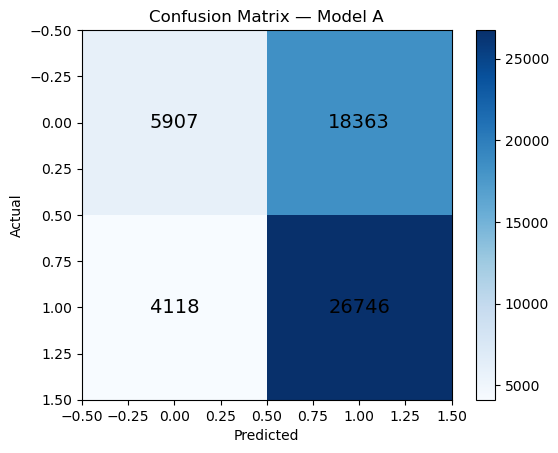

In [32]:


cm = confusion_matrix(y_test_A, preds_A)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix — Model A")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.show()



In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_A, preds_A)
recall = recall_score(y_test_A, preds_A)
f1 = f1_score(y_test_A, preds_A)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1: {f1:.2f}")

Precision: 0.59
Recall: 0.87
F1: 0.70


### 8) Decide Which Model Is “Better” — Explain Your Metric Choice

- If the **cost of missing a Critical** violation is high → prioritize **Recall** on the positive class.  
- If the **cost of wrongly flagging Critical** is high → prioritize **Precision** on the positive class.  
- If you want a balance → **F1**.

Write 3–5 sentences justifying your pick using the table above (Precision/Recall/F1).

- I chose Model A because it delivered the highest Recall score for the Critical class. Since public health inspections prioritize catching risky restaurants rather than avoiding false alarms, Recall matters more than Precision in this context. Model A successfully identified 87% of restaurants that truly had Critical violations, making it the strongest model for protecting public safety.

## We Share (Reflection)

1) **Chosen model (A/B/C)** and **why**, referencing **Precision/Recall/F1** for the **Critical (1)** class.  
Using Model A, the confusion matrix shows how well the model predicted Critical versus Not Critical inspections. Out of all inspections the model predicted as 'Critical', about 59% were actually Critical (precision). Out of all inspections that truly had a Critical violation, the model successfully identified about 87%, meaning it caught most of the real Critical cases (recall). In other words the model may have some false alarms, but it rarely misses a real Critical violation, which makes it useful for preventing violations and overall health safetly. 
2) Your **confusion matrix** and a one-liner in plain English:  
   - “Out of all inspections we predicted **Critical**, **X%** were actually Critical (Precision).  
   - Of all actually **Critical** inspections, we caught **Y%** (Recall).”  

- Using Model A, the confusion matrix shows the model’s performance on predicting Critical violations.
- Out of all inspections we predicted as Critical, about 59% were actually Critical (Precision).
- Of all inspections that were truly Critical, the model correctly caught about 87% (Recall).